In [1]:
import pandas as pd
import matplotlib.pyplot as plt

deals_df = pd.read_csv("clear_deals.csv")
projects_df = pd.read_csv("clear_projects.csv")

In [39]:
projects_buildings_df = (
    projects_df
    .groupby("id_корпуса")
    .agg(
        # стадия строительства корпус
        стадия_строительства=("стадия_строительства", "first"),

        # этажность дома
        building_floors_count=("этаж", "nunique"),

        # общее количество квартир в корпусе
        total_flats_in_building=("количество_лотов", "sum"),

        плановая_дата_рвэ=("плановая_дата_рвэ", "first"),
    )
    .reset_index()
)

projects_buildings_df.head()


,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,плановая_дата_рвэ
0,002b4f20e97d6ca8ac349b5e2e9e81d3,Монтажные и отделочные работы,16,333,2025-12-31
1,0076fc28a53eb506b7fc91475d31dea3,Монтажные и отделочные работы,10,235,2025-08-14
2,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,18,732,2025-08-21
3,009d5290e93e353bb27e3f01b505f5b7,Монтажные и отделочные работы,16,703,2026-12-31
4,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,18,190,2025-06-17


In [40]:
deals_count_by_building_df = (
    deals_df
    .groupby("id_корпуса")
    .size()
    .reset_index(name="deals_count")
)

deals_count_by_building_df.head()


,id_корпуса,deals_count
0,002b4f20e97d6ca8ac349b5e2e9e81d3,267
1,0076fc28a53eb506b7fc91475d31dea3,98
2,0081bc4d4059f46b3b42276ba8aee782,312
3,009d5290e93e353bb27e3f01b505f5b7,28
4,013e43142be6303646e81ccd28432986,154


In [41]:
projects_buildings_df = projects_buildings_df.merge(
    deals_count_by_building_df,
    on="id_корпуса",
    how="left"
)

# если по корпусу не было сделок
projects_buildings_df["deals_count"] = (
    projects_buildings_df["deals_count"]
    .fillna(0)
    .astype(int)
)


In [42]:
projects_buildings_df

,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,плановая_дата_рвэ,deals_count
0,002b4f20e97d6ca8ac349b5e2e9e81d3,Монтажные и отделочные работы,16,333,2025-12-31,267
1,0076fc28a53eb506b7fc91475d31dea3,Монтажные и отделочные работы,10,235,2025-08-14,98
2,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,18,732,2025-08-21,312
3,009d5290e93e353bb27e3f01b505f5b7,Монтажные и отделочные работы,16,703,2026-12-31,28
4,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,18,190,2025-06-17,154
...,...,...,...,...,...,...
414,fd01b8c0e5ea83c9252268d6806cf6e6,Монтажные и отделочные работы,21,465,2027-03-31,73
415,fd11279466f6069c8fefd1baa5884d18,Введен в эксплуатацию,15,535,2023-06-30,134
416,fde1f8ad4322f757d44bdf4c634df283,Введен в эксплуатацию,19,945,2025-05-30,153
417,fe3fbf2588f1c241871893ab71fee571,Монтажные и отделочные работы,10,68,2026-06-30,34


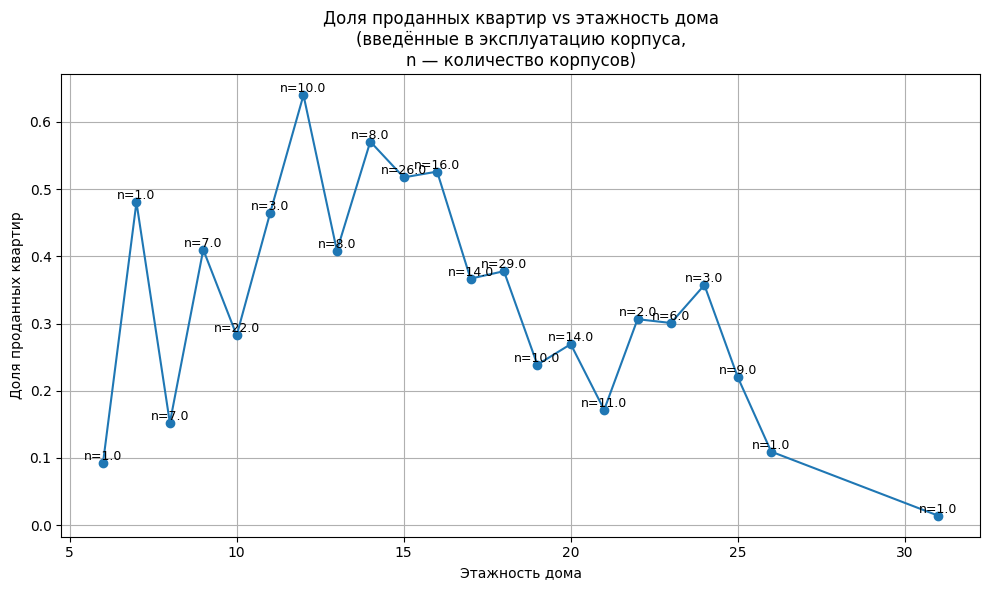

In [ ]:
commissioned_buildings_df = projects_buildings_df[
    projects_buildings_df["стадия_строительства"] != "Введен в эксплуатацию"
].copy()

commissioned_buildings_df["sales_share"] = (
    commissioned_buildings_df["deals_count"]
    / commissioned_buildings_df["total_flats_in_building"]
)

height_sales_share_commissioned_df = (
    commissioned_buildings_df
    .groupby("building_floors_count")
    .agg(
        mean_sales_share=("sales_share", "mean"),
        buildings_count=("id_корпуса", "count")
    )
    .reset_index()
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    height_sales_share_commissioned_df["building_floors_count"],
    height_sales_share_commissioned_df["mean_sales_share"],
    marker="o"
)

# подписи n над точками
for _, row in height_sales_share_commissioned_df.iterrows():
    plt.text(
        row["building_floors_count"],
        row["mean_sales_share"],
        f'n={row["buildings_count"]}',
        fontsize=9,
        ha='center',
        va='bottom'
    )

plt.xlabel("Этажность дома")
plt.ylabel("Доля проданных квартир")
plt.title(
    "Доля проданных квартир vs этажность дома\n"
    "(введённые в эксплуатацию корпуса,\n"
    "n — количество корпусов)"
)

plt.grid(True)
plt.tight_layout()
plt.show()



Коэффициент наклона (β1): -0.0092
Свободный член (β0): 0.5203
R² (взвешенный): 0.098


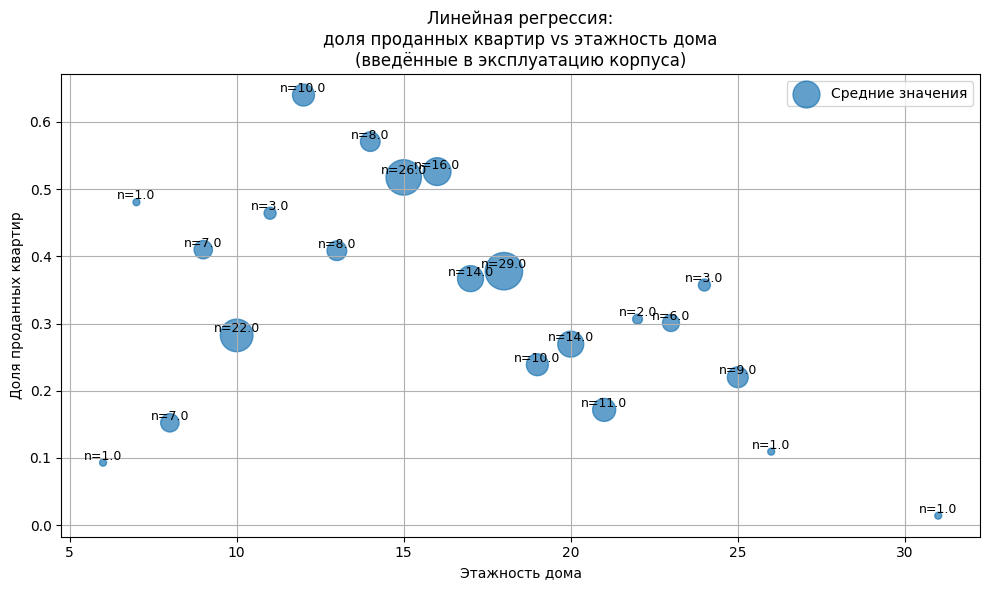

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# X, y, веса
X = height_sales_share_commissioned_df["building_floors_count"].values.reshape(-1, 1)
y = height_sales_share_commissioned_df["mean_sales_share"].values
weights = height_sales_share_commissioned_df["buildings_count"].values

# модель
lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=weights)

# предсказания
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

# коэффициенты
slope = lin_reg.coef_[0]
intercept = lin_reg.intercept_
r2 = lin_reg.score(X, y, sample_weight=weights)

print(f"Коэффициент наклона (β1): {slope:.4f}")
print(f"Свободный член (β0): {intercept:.4f}")
print(f"R² (взвешенный): {r2:.3f}")

plt.figure(figsize=(10, 6))

# точки
plt.scatter(
    height_sales_share_commissioned_df["building_floors_count"],
    height_sales_share_commissioned_df["mean_sales_share"],
    s=height_sales_share_commissioned_df["buildings_count"] * 25,
    alpha=0.7,
    label="Средние значения"
)

# # линия регрессии
# plt.plot(
#     x_line,
#     y_line,
#     linestyle="--",
#     label="Линейная регрессия"
# )

# подписи n
for _, row in height_sales_share_commissioned_df.iterrows():
    plt.text(
        row["building_floors_count"],
        row["mean_sales_share"],
        f'n={row["buildings_count"]}',
        fontsize=9,
        ha='center',
        va='bottom'
    )

plt.xlabel("Этажность дома")
plt.ylabel("Доля проданных квартир")
plt.title(
    "Линейная регрессия:\n"
    "доля проданных квартир vs этажность дома\n"
    "(введённые в эксплуатацию корпуса)"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Коэффициент наклона (β1): -0.0004
Свободный член (β0): 0.7469
R²: 0.360


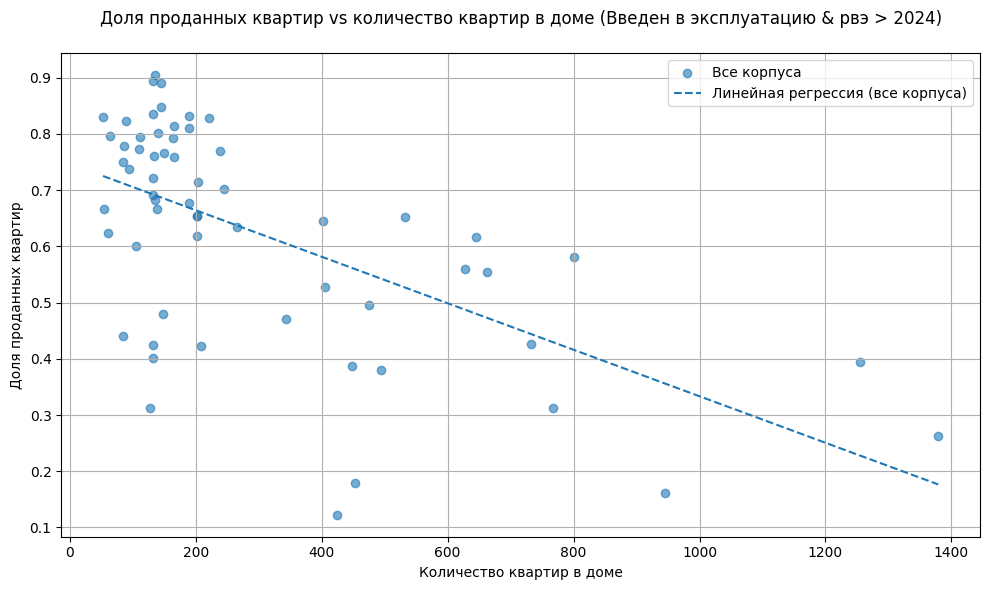

In [95]:
import matplotlib.pyplot as plt

projects_buildings_df["плановая_дата_рвэ"] = pd.to_datetime(
    projects_buildings_df["плановая_дата_рвэ"],
    errors="coerce"
)

buildings_2023_df = projects_buildings_df[
    (projects_buildings_df["стадия_строительства"] == "Введен в эксплуатацию") &
    (projects_buildings_df["плановая_дата_рвэ"].dt.year > 2024)
].copy()

buildings_2023_df["sales_share"] = (
    buildings_2023_df["deals_count"]
    / buildings_2023_df["total_flats_in_building"]
)

X = buildings_2023_df["total_flats_in_building"].values.reshape(-1, 1)
y = buildings_2023_df["sales_share"].values

model_all = LinearRegression()
model_all.fit(X, y)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model_all.predict(x_line)

print(f"Коэффициент наклона (β1): {model_all.coef_[0]:.4f}")
print(f"Свободный член (β0): {model_all.intercept_:.4f}")
print(f"R²: {model_all.score(X, y):.3f}")

plt.figure(figsize=(10, 6))

plt.scatter(
    buildings_2023_df["total_flats_in_building"],
    buildings_2023_df["sales_share"],
    alpha=0.6,
    label="Все корпуса"
)

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    label="Линейная регрессия (все корпуса)"
)

plt.xlabel("Количество квартир в доме")
plt.ylabel("Доля проданных квартир")
plt.title("Доля проданных квартир vs количество квартир в доме (Введен в эксплуатацию & рвэ > 2024)\n")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [108]:
import numpy as np
from scipy.stats import ttest_ind
# берём нужные данные
df = buildings_2023_df.copy()

# медиана по количеству квартир
median_flats = df["total_flats_in_building"].median()
print(f"Медиана количества квартир: {median_flats}")
group_small = df[df["total_flats_in_building"] <= median_flats]["sales_share"]
group_large = df[df["total_flats_in_building"] > median_flats]["sales_share"]

print(f"Размер группы малых домов: {len(group_small)}")
print(f"Размер группы крупных домов: {len(group_large)}")
t_stat, p_value = ttest_ind(
    group_small,
    group_large,
    equal_var=False,
    nan_policy="omit"
)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

print("Средняя доля — малые дома:", group_small.mean())
print("Средняя доля — крупные дома:", group_large.mean())



Медиана количества квартир: 166.0
Размер группы малых домов: 31
Размер группы крупных домов: 30
t-статистика: 3.899
p-value: 0.0003
Средняя доля — малые дома: 0.7114801533076381
Средняя доля — крупные дома: 0.5348309043311478


In [111]:
low_share_df = buildings_2023_df[
    buildings_2023_df["sales_share"] < 0.2
].copy()

low_share_df

,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,плановая_дата_рвэ,deals_count,sales_share,рвэ
147,560d317beb5ecd1e1cf087f1d1ce12fe,Введен в эксплуатацию,25,453,2025-08-11,81,0.178808,2025.583333
317,be189522ad2911655fc4f24c4d204b68,Введен в эксплуатацию,20,424,2025-09-04,52,0.122642,2025.666667
416,fde1f8ad4322f757d44bdf4c634df283,Введен в эксплуатацию,19,945,2025-05-30,153,0.161905,2025.333333


β1 (наклон): 0.0605
β0 (свободный член): -121.8563
R²: 0.004


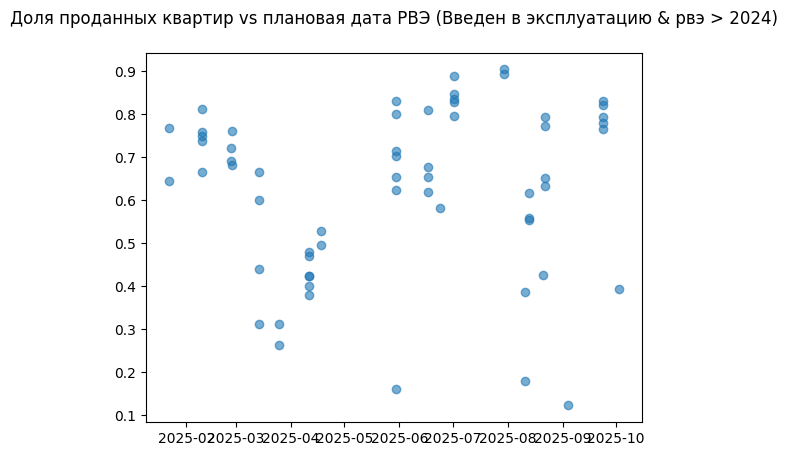

In [109]:
buildings_2023_df["рвэ"] = (
    buildings_2023_df["плановая_дата_рвэ"].dt.year +
    (buildings_2023_df["плановая_дата_рвэ"].dt.month - 1) / 12
)

X = buildings_2023_df["рвэ"].values.reshape(-1, 1)
y = buildings_2023_df["sales_share"].values

model_all = LinearRegression()
model_all.fit(X, y)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model_all.predict(x_line)

print(f"β1 (наклон): {model_all.coef_[0]:.4f}")
print(f"β0 (свободный член): {model_all.intercept_:.4f}")
print(f"R²: {model_all.score(X, y):.3f}")

plt.scatter(
    buildings_2023_df["плановая_дата_рвэ"],
    buildings_2023_df["sales_share"],
    alpha=0.6,
    label="Все корпуса"
)

# plt.plot(
#     x_line,
#     y_line,
#     linestyle="--",
#     label="Линейная регрессия (все корпуса)"
# )

plt.title("Доля проданных квартир vs плановая дата РВЭ (Введен в эксплуатацию & рвэ > 2024)\n")
plt.show()

In [38]:
projects_buildings_df = (
    projects_df
    .groupby("id_корпуса")
    .agg(
        # стадия строительства корпус
        стадия_строительства=("стадия_строительства", "first"),

        # этажность дома
        building_floors_count=("этаж", "nunique"),

        # общее количество квартир в корпусе
        total_flats_in_building=("количество_лотов", "sum"),

    )
    .reset_index()
)

projects_buildings_df.head()

deals_count_by_building_df = (
    deals_df
    .groupby("id_корпуса")
    .size()
    .reset_index(name="deals_count")
)

deals_count_by_building_df.head()

projects_buildings_df = projects_buildings_df.merge(
    deals_count_by_building_df,
    on="id_корпуса",
    how="left"
)

# если по корпусу не было сделок
projects_buildings_df["deals_count"] = (
    projects_buildings_df["deals_count"]
    .fillna(0)
    .astype(int)
)

projects_buildings_df

,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,deals_count
0,002b4f20e97d6ca8ac349b5e2e9e81d3,Монтажные и отделочные работы,16,333,267
1,0076fc28a53eb506b7fc91475d31dea3,Монтажные и отделочные работы,10,235,98
2,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,18,732,312
3,009d5290e93e353bb27e3f01b505f5b7,Монтажные и отделочные работы,16,703,28
4,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,18,190,154
...,...,...,...,...,...
414,fd01b8c0e5ea83c9252268d6806cf6e6,Монтажные и отделочные работы,21,465,73
415,fd11279466f6069c8fefd1baa5884d18,Введен в эксплуатацию,15,535,134
416,fde1f8ad4322f757d44bdf4c634df283,Введен в эксплуатацию,19,945,153
417,fe3fbf2588f1c241871893ab71fee571,Монтажные и отделочные работы,10,68,34
